In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../output/combined_projections.csv")

In [3]:
df_long = df.melt(
    id_vars=["model_name", "model_variation", "dimension"], 
    value_vars=["female_names", "male_names"], 
    var_name="gender", 
    value_name="score"
)
df_long["gender"] = df_long["gender"].str.replace("_names", "").str.capitalize()

def get_group(val):
    if "default" in val:
        return "Default"
    for v in ["conservative", "democratic", "liberal"]:
        if v in val:
            return v.capitalize()
    return "Other"

df_long["variation_group"] = df_long["model_variation"].apply(get_group)

In [4]:
#df_long = df_long[~(df_long["model_name"].str.contains("Qwen"))].reset_index()
#df_long

In [5]:
from scipy.stats import wilcoxon, ttest_1samp

default_map = df_long[df_long["variation_group"] == "Default"].set_index(
    ["model_name", "dimension", "gender"]
)["score"]

def perform_ttest(group):
    model, var_group, dim, gender = group.name
    baseline = default_map.loc[(model, dim, gender)]
    
    # T-Test
    t_stat, p_val = ttest_1samp(group["score"], popmean=baseline[0])
    return p_val

variations_only = df_long[df_long["variation_group"] != "Default"]

p_values_series = variations_only.groupby(
    ["model_name", "variation_group", "dimension", "gender"]
).apply(perform_ttest, include_groups=False)

significance_df = p_values_series.reset_index(name="p_value")

/tmp/ipykernel_965335/4113146549.py:9: PerformanceWarning: indexing past lexsort depth may impact performance.
  baseline = default_map.loc[(model, dim, gender)]
/tmp/ipykernel_965335/4113146549.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  t_stat, p_val = ttest_1samp(group["score"], popmean=baseline[0])


Plotting: Apertus-8B-Instruct-2509
Plotting: Meta-Llama-3-8B
Plotting: Qwen3-8B


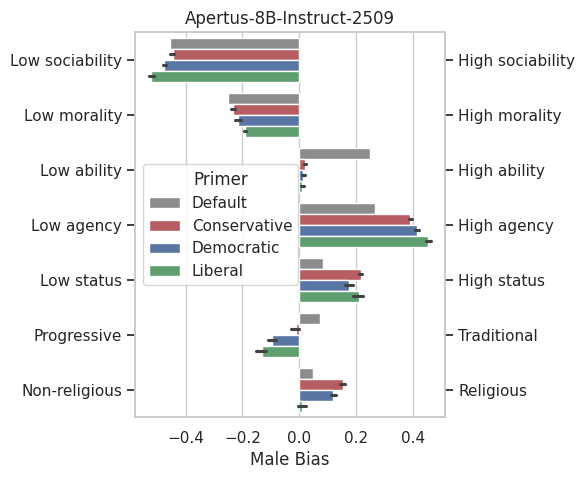

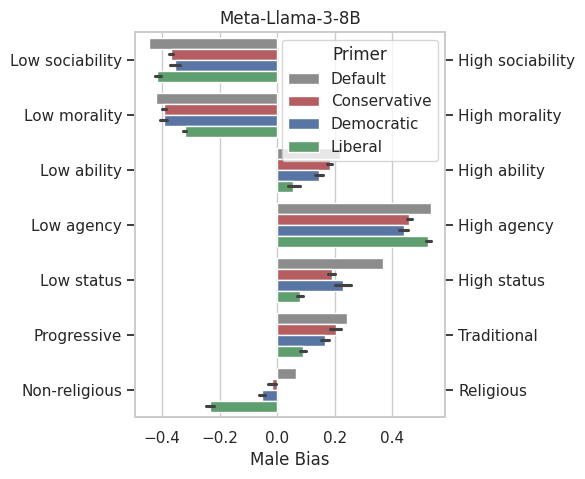

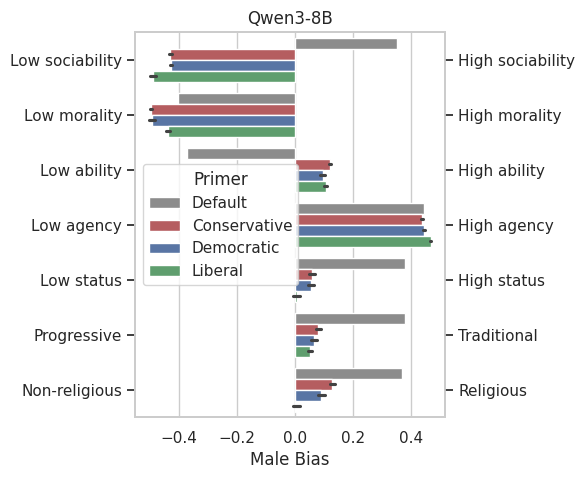

In [12]:
alpha = 0.01

target_aspects = ["Conservative", "Democratic", "Liberal"]

male_palette = {
    "Default": sns.color_palette()[7],
    "Conservative": sns.color_palette()[3], 
    "Liberal": sns.color_palette()[2],      
    "Democratic": sns.color_palette()[0]    
}

low_labels = {
    "Sociability": "Low sociability",
    "Morality": "Low morality",
    "Ability": "Low ability",
    "Agency": "Low agency",
    "Status": "Low status",
    "Politics": "Progressive",
    "Religion": "Non-religious"
}

high_labels = {
    "Sociability": "High sociability",
    "Morality": "High morality",
    "Ability": "High ability",
    "Agency": "High agency",
    "Status": "High status",
    "Politics": "Traditional",
    "Religion": "Religious"
}

for model in df_long["model_name"].unique():
    print(f"Plotting: {model}")
    
    subset_df = df_long[
        (df_long["model_name"] == model)
    ].copy()
    
    sns.set_theme(style="whitegrid")
    fig, ax = plt.subplots(figsize=(4, 5))

    ax.set_title(f"{model}")

    ax = plt.gca()
    
    # Male Lines
    sns.barplot(
        data=subset_df[subset_df["gender"] == "Male"],
        x="score", y="dimension", hue="variation_group",
        palette = male_palette,
        ax=ax
    )
    
    if ax.get_legend():
        ax.get_legend().set_title("Primer")
    
    ax.set_xlabel("Male Bias")
    ax.set_ylabel("")
    
    fig.canvas.draw()
    
    bold_rows = []
    
    for dim in low_labels.keys():
    #    l_text = low_labels.get(dim, dim)
    #    r_text = high_labels.get(dim, dim)
    #    p_female_row = significance_df[
    #        (significance_df["model_name"] == model) & 
    #        (significance_df["dimension"] == dim) & 
    #        (significance_df["gender"] == "Female") &
    #        (significance_df["variation_group"] == aspect)
    #    ]
    #    p_f = p_female_row["p_value"].values[0]
    #    p_male_row = significance_df[
    #        (significance_df["model_name"] == model) & 
    #        (significance_df["dimension"] == dim) & 
    #        (significance_df["gender"] == "Male") &
    #        (significance_df["variation_group"] == aspect)
    #    ]
    #    p_m = p_male_row["p_value"].values[0]
    #
    #    bold_rows.append(p_f < alpha and p_m < alpha)
        bold_rows.append(False)

    ax.set_yticks(ax.get_yticks())
    ax.set_yticklabels(low_labels.values())
    
    ax.tick_params(labelright=True, right=True)
    ax2 = ax.twinx()
    ax2.set_ylim(ax.get_ylim()) 
    ax2.set_yticks(ax.get_yticks())      
    ax2.set_yticklabels(high_labels.values())

    for i, (label1, label2) in enumerate(zip(ax.get_yticklabels(), ax2.get_yticklabels())):
        if bold_rows[i]:
            label1.set_fontweight('bold')
            label2.set_fontweight('bold')
    
    ax2.grid(False)

    plt.savefig(f"../figures/{model}.pdf", bbox_inches='tight')
    plt.savefig(f"../figures/{model}.png", bbox_inches='tight', dpi=600)